# Student Performance Analytics Dashboard — Data Analysis Notebook

This notebook documents the full data analysis workflow behind the **Student Performance Analytics Dashboard**. It covers data loading, cleaning, feature engineering, outlier handling, exploratory data analysis (EDA), and the key insights derived from the dataset.

**Dataset:** `student-scores.csv`

**Workflow overview:**
1. Import libraries
2. Load the dataset
3. Handle missing values
4. Remove duplicate records
5. Engineer the `average_score` feature
6. Detect and remove outliers (IQR method)
7. Generate summary statistics
8. Exploratory visualizations
9. Correlation analysis
10. Key insights and top performers
11. Export the cleaned dataset


## 1. Import Libraries

We use **pandas** and **numpy** for data manipulation, **plotly express** for interactive charts, and **seaborn/matplotlib** for the correlation heatmap.


In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)



## 2. Load the Dataset

The raw dataset is read into a pandas DataFrame. Before any cleaning, we take a quick look at its shape and structure.


In [2]:

df = pd.read_csv("../data/raw_dataset.csv")

print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Shape: 2000 rows, 17 columns


,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   id                          2000 non-null   int64 
 1   first_name                  2000 non-null   object
 2   last_name                   2000 non-null   object
 3   email                       2000 non-null   object
 4   gender                      2000 non-null   object
 5   part_time_job               2000 non-null   bool  
 6   absence_days                2000 non-null   int64 
 7   extracurricular_activities  2000 non-null   bool  
 8   weekly_self_study_hours     2000 non-null   int64 
 9   career_aspiration           2000 non-null   object
 10  math_score                  2000 non-null   int64 
 11  history_score               2000 non-null   int64 
 12  physics_score               2000 non-null   int64 
 13  chemistry_score             2000 non-null   int6

## 3. Handle Missing Values

Missing values are handled differently depending on the column type:
- **Numeric columns** → filled with the column **mean**
- **Categorical columns** → filled with the column **mode** (most frequent value)

This ensures no rows are dropped purely due to missing data, preserving sample size for analysis.

In [4]:
print("Missing values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values before cleaning:
Series([], dtype: int64)


In [5]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

categorical_cols = df.select_dtypes(exclude=np.number).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum().sum(), "total missing values remaining")


Missing values after cleaning:
0 total missing values remaining


## 4. Remove Duplicate Records

Exact duplicate rows can bias averages and distort visualizations, so they are identified and removed.


In [6]:
rows_before = len(df)

duplicates_removed = df.duplicated().sum()
df.drop_duplicates(inplace=True)

print(f"Duplicate rows removed: {duplicates_removed}")
print(f"Rows remaining: {len(df)}")


Duplicate rows removed: 0
Rows remaining: 2000


## 5. Feature Engineering — Average Score

A single composite metric, `average_score`, is created by averaging each student's scores across all seven subjects. This becomes the primary performance metric used throughout the analysis.


In [7]:
score_columns = [
    "math_score",
    "history_score",
    "physics_score",
    "chemistry_score",
    "biology_score",
    "english_score",
    "geography_score"
]

df["average_score"] = df[score_columns].mean(axis=1)
df[["first_name", "last_name", "average_score"]].head()


,first_name,last_name,average_score
0,Paul,Casey,82.000000
1,Danielle,Sandoval,91.428571
2,Tina,Andrews,86.428571
3,Tara,Clark,78.714286
4,Anthony,Campos,74.428571


## 6. Outlier Detection & Removal (IQR Method)

Outliers in `average_score` are detected using the **Interquartile Range (IQR)** method:

$$IQR = Q3 - Q1$$

Any value below $Q1 - 1.5 \times IQR$ or above $Q3 + 1.5 \times IQR$ is treated as an outlier and removed. This prevents a small number of extreme scores from skewing the overall analysis.


In [8]:
Q1 = df["average_score"].quantile(0.25)
Q3 = df["average_score"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_removed = len(
    df[(df["average_score"] < lower_bound) | (df["average_score"] > upper_bound)]
)

df = df[(df["average_score"] >= lower_bound) & (df["average_score"] <= upper_bound)]

rows_after = len(df)

print(f"Outliers removed: {outliers_removed}")
print(f"Final dataset size: {rows_after} rows (started with {rows_before})")


Outliers removed: 26
Final dataset size: 1974 rows (started with 2000)


## 7. Dataset Overview & Summary Statistics

A quick statistical summary of the cleaned dataset confirms the data is ready for analysis — no missing values, no duplicates, and outliers removed.


In [9]:
summary_stats = pd.DataFrame({
    "Rows Before Cleaning": [rows_before],
    "Rows After Cleaning": [rows_after],
    "Duplicates Removed": [duplicates_removed],
    "Outliers Removed": [outliers_removed]
})
summary_stats


,Rows Before Cleaning,Rows After Cleaning,Duplicates Removed,Outliers Removed
0,2000,1974,0,26


In [10]:
df.describe()


,id,absence_days,weekly_self_study_hours,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score,average_score
count,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000
mean,999.499493,3.638804,17.867781,83.747720,80.501013,81.494934,80.183384,79.713779,81.441236,80.986829,81.152699
std,578.476109,2.616129,12.083434,12.884067,12.605952,12.427457,12.654231,13.603488,11.859857,11.622497,5.771453
min,1.000000,0.000000,0.000000,40.000000,50.000000,50.000000,50.000000,30.000000,50.000000,60.000000,66.285714
25%,498.250000,2.000000,5.000000,77.000000,70.000000,71.000000,69.000000,69.000000,73.000000,71.000000,77.428571
50%,999.500000,3.000000,18.000000,87.000000,82.000000,83.000000,81.000000,81.000000,83.000000,81.000000,81.142857
75%,1500.750000,5.000000,28.000000,93.000000,91.000000,92.000000,91.000000,91.000000,91.000000,91.000000,84.714286
max,2000.000000,10.000000,50.000000,100.000000,100.000000,100.000000,100.000000,100.000000,99.000000,100.000000,95.714286


## 8. Exploratory Data Analysis & Visualizations

The following charts explore how different factors relate to student performance: score distribution, gender, study habits, attendance, career aspirations, and part-time employment.


### 8.1 Distribution of Average Scores

Shows the overall spread of student performance after cleaning.


In [ ]:

fig1 = px.histogram(
    df,
    x="average_score",
    nbins=25,
    title="Distribution of Average Scores"
)
fig1.show()


### 8.2 Average Score by Gender

Compares mean performance between genders.


In [12]:
gender_avg = df.groupby("gender")["average_score"].mean().reset_index()

fig2 = px.bar(
    gender_avg,
    x="gender",
    y="average_score",
    text_auto=".2f",
    title="Average Score by Gender"
)
fig2.show()


### 8.3 Study Hours vs. Average Score

Examines whether more weekly self-study hours correlate with better performance.


In [13]:
fig3 = px.scatter(
    df,
    x="weekly_self_study_hours",
    y="average_score",
    color="gender",
    title="Study Hours vs Average Score"
)
fig3.show()


### 8.4 Distribution of Absence Days

Looks at how attendance patterns are spread across the student population.


In [14]:
fig4 = px.histogram(
    df,
    x="absence_days",
    title="Distribution of Absence Days"
)
fig4.show()


### 8.5 Career Aspiration Distribution

Highlights the most and least common career goals among students.


In [15]:
career_counts = df["career_aspiration"].value_counts().sort_values().reset_index()
career_counts.columns = ["Career", "Count"]

fig5 = px.bar(
    career_counts,
    x="Count",
    y="Career",
    orientation="h",
    text="Count",
    title="Career Aspiration Distribution"
)
fig5.update_layout(height=650)
fig5.show()


### 8.6 Part-Time Job Impact on Performance

Boxplot comparing score distributions for students with and without a part-time job.


In [16]:
fig6 = px.box(
    df,
    x="part_time_job",
    y="average_score",
    title="Part-Time Job Impact on Academic Performance"
)
fig6.show()


## 9. Correlation Heatmap

A correlation matrix between study habits, absences, subject scores, and overall average score reveals which factors move together most strongly.


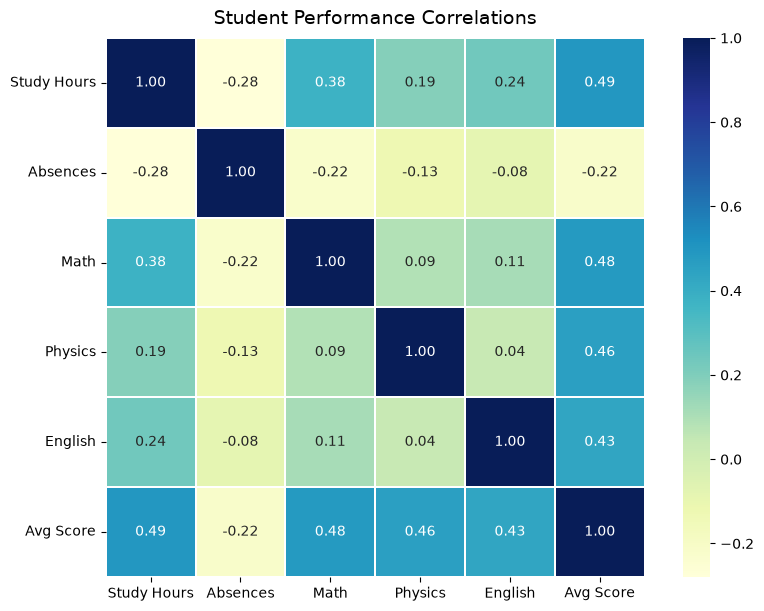

In [17]:
heatmap_df = df[[
    "weekly_self_study_hours",
    "absence_days",
    "math_score",
    "physics_score",
    "english_score",
    "average_score"
]].copy()

heatmap_df.columns = ["Study Hours", "Absences", "Math", "Physics", "English", "Avg Score"]

corr = heatmap_df.corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.1,
    square=True,
    cbar=True,
    annot_kws={"size": 10}
)
ax.set_title("Student Performance Correlations", fontsize=14, pad=10)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()


## 10. Top 10 Performing Students

The highest-scoring students, ranked by average score.


In [18]:
top_students = df.sort_values("average_score", ascending=False).head(10)
top_students[["first_name", "last_name", "average_score", "career_aspiration"]]


,first_name,last_name,average_score,career_aspiration
551,Paul,Shaffer,95.714286,Software Engineer
1419,Mary,Arnold,95.714286,Designer
1122,Daniel,Lewis,95.285714,Doctor
163,Nicholas,Clayton,95.285714,Doctor
985,Lance,Nelson,95.142857,Unknown
541,Scott,Weaver,95.000000,Construction Engineer
718,Kelly,Morris,95.000000,Software Engineer
548,Eric,Murray,94.714286,Doctor
809,Brianna,Gutierrez,94.714286,Scientist
721,Mark,Brown,94.571429,Unknown


## 11. Key Findings

- Students with higher self-study hours generally achieve better academic performance.
- Higher absence days tend to lower academic scores.
- Math, Physics, and English scores are positively correlated with each other.
- Individual academic subjects have a strong relationship with the overall `average_score`.
- Career aspirations vary significantly across the student population.
- Part-time jobs show only a small impact on overall academic outcomes.


## 12. Export Cleaned Dataset

The cleaned and processed dataset is saved to disk so it can be reused directly by the Streamlit dashboard (`app.py`) without repeating the cleaning steps.


In [19]:
df.to_csv("cleaned_student_scores.csv", index=False)
print("Cleaned dataset saved as cleaned_student_scores.csv")


Cleaned dataset saved as cleaned_student_scores.csv
